In [1]:
%matplotlib widget

In [22]:
import numpy as np
import pygimli as pg
import empymod as ep
from sklearn.metrics import root_mean_squared_error
import matplotlib.pyplot as plt
import sys
sys.path.insert(1, 'src')

from FDEM1D import FDEM1DModelling_nosort
from showStitched import showStitchedModels
from Plot import grid

In [72]:
# model_true

x = np.linspace(0, 70, 70, endpoint=False)

h_a = x.copy()
h_a[:10] = np.sin(x[10]/10) + 1.5
h_a[10:60] = np.sin(x[10:60]/10) + 1.5
h_a[60:] = np.sin(x[60]/10) + 1.5
h_1 = 3- h_a

s_a = np.ones_like(x) * 1 /1e6
s_1 = np.ones_like(x) * 100/1000
s_2 = np.ones_like(x) * 10/1000

model_topo = np.array([h_a, h_1, s_a, s_1, s_2]).T
model_true = np.array([h_1[:62], s_1[:62], s_2[:62]]).T

In [73]:
data_true =  np.load('data_3D_parallel_test3.npy')

In [74]:
#data_Q = data_true[:,:6].copy() #cut out V coil
#data_IP = data_true[:,9:15].copy()
#data_true = np.hstack((data_Q, data_IP))


In [75]:
# number of measurement positions 
npos = len(data_true)

# Setting forward operator 

fop = FDEM1DModelling_nosort(nlay=2)

transThk = pg.trans.TransLogLU(0.5,3)
transSig = pg.trans.TransLogLU(5/1000,200/1000)

fop.region(0).setTransModel(transThk)
fop.region(1).setTransModel(transSig)

# Perform inversion in each position

startModel = np.array([2, 0.05, 0.05]) # initial model

model_inv = []
response = []

for pos in range(npos):
    dat = data_true[pos]
    rel_err = np.ones_like(dat)*1e-3 
    inv = pg.Inversion(fop)
    model_inv.append(inv.run(dataVals=dat, errorVals=rel_err, startModel=startModel, verbose=False, lam=1 ))
    response.append(inv.response)

In [76]:
model_inv = np.array(model_inv)
response = np.array(response)
model_inv_topo = np.array([h_a[:62], model_inv[:,0], s_a[:62], model_inv[:,1], model_inv[:,2]]).T

In [77]:
model_h_rmse = root_mean_squared_error(model_true[:,0].ravel(), model_inv[:,0].ravel())
model_s_rmse = root_mean_squared_error(model_true[:,1:].ravel(), model_inv[:,1:].ravel())*1000
data_rmse = root_mean_squared_error(data_true.ravel(), response.ravel())*1000

(-4.0, 0.0)

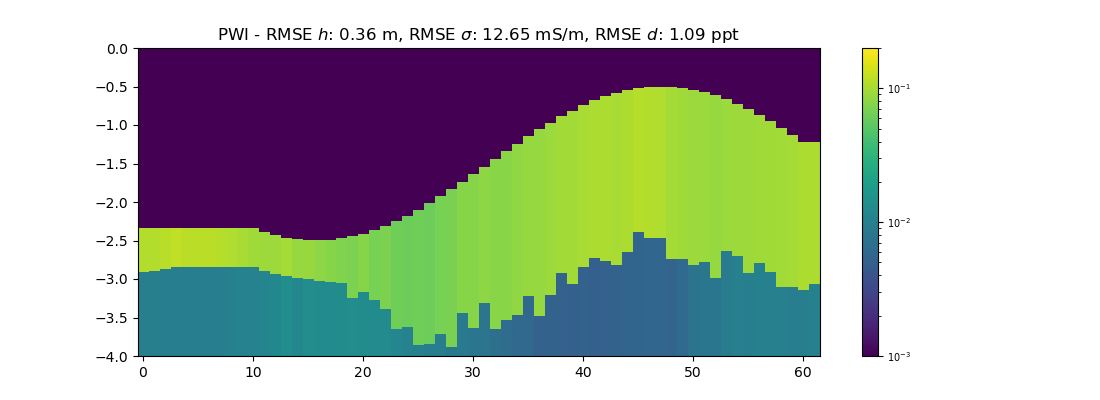

In [82]:
fig, ax = plt.subplots(figsize=(11,4))
showStitchedModels(model_inv_topo, zMax=4, cMin=1/1000, cMax=0.2, ax=ax)
ax.set_title(f'PWI - RMSE $h$: {model_h_rmse:.2f} m, RMSE $\sigma$: {model_s_rmse:.2f} mS/m, RMSE $d$: {data_rmse:.2f} ppt')
ax.set_ylim([-4, 0])

(-4.0, 0.0)

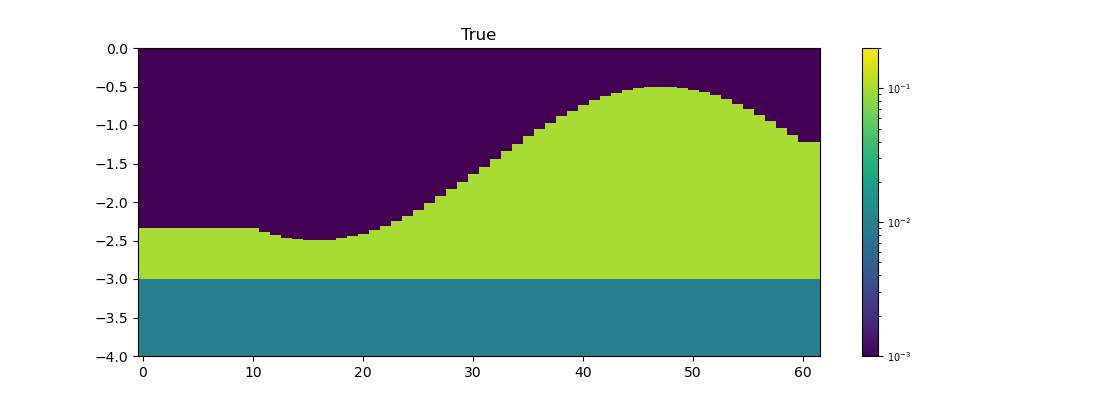

In [83]:
fig, ax = plt.subplots(figsize=(11,4))
showStitchedModels(model_topo[:62], zMax=4,cMin=1/1000, cMax=0.2, ax=ax)
ax.set_title('True')
ax.set_ylim([-4, 0])

In [80]:
model_true_g = grid(model_topo[:62], depthmax=4, nlay=3)
model_inv_g = grid(model_inv_topo, depthmax=4, nlay=3)

diff_g = np.abs(model_true_g - model_inv_g)*1000

(-4.0, 0.0)

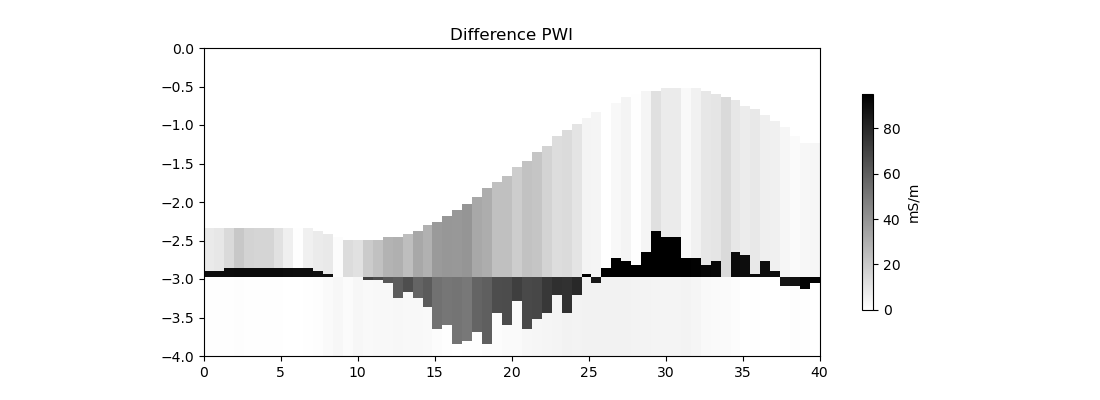

In [84]:
fig, ax = plt.subplots(figsize=(11,4))

c = ax.imshow(diff_g.T, extent = [0,40, -4, 0], aspect=5, cmap='binary')
fig.colorbar(c, label='mS/m', shrink=0.7)
ax.set_title('Difference PWI')
ax.set_ylim([-4, 0])

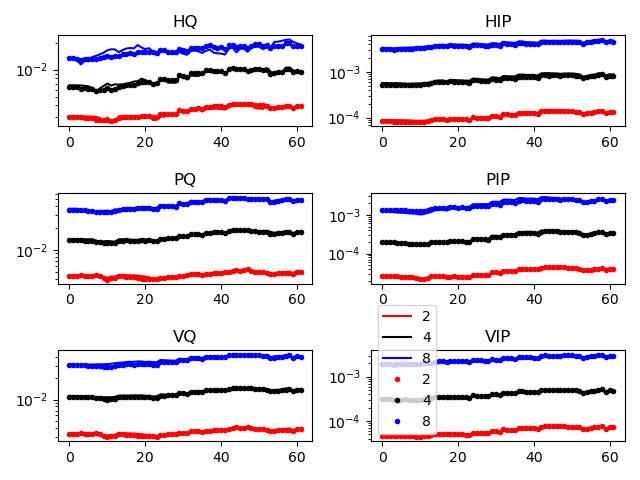

In [71]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(3,2)

ax[0,0].semilogy(data_true[:,0], 'r', label='2')
ax[0,0].semilogy(data_true[:,1], 'k', label='4')
ax[0,0].semilogy(data_true[:,2], 'b', label='8')
ax[0,0].semilogy(response[:,0], '.r', label='2')
ax[0,0].semilogy(response[:,1], '.k', label='4')
ax[0,0].semilogy(response[:,2], '.b', label='8')

ax[0,0].set_title('HQ')
#ax[0,0].legend()

ax[1,0].semilogy(data_true[:,3], 'r', label='2')
ax[1,0].semilogy(data_true[:,4], 'k', label='4')
ax[1,0].semilogy(data_true[:,5], 'b', label='8')
ax[1,0].semilogy(response[:,3], '.r', label='2')
ax[1,0].semilogy(response[:,4], '.k', label='4')
ax[1,0].semilogy(response[:,5], '.b', label='8')
ax[1,0].set_title('PQ')
#ax[1,0].legend()

ax[2,0].semilogy(data_true[:,6], 'r', label='2')
ax[2,0].semilogy(data_true[:,7], 'k', label='4')
ax[2,0].semilogy(data_true[:,8], 'b', label='8')
ax[2,0].semilogy(response[:,6], '.r', label='2')
ax[2,0].semilogy(response[:,7], '.k', label='4')
ax[2,0].semilogy(response[:,8], '.b', label='8')
ax[2,0].set_title('VQ')
#ax[2,0].legend()

ax[0,1].semilogy(data_true[:,9], 'r', label='2')
ax[0,1].semilogy(data_true[:,10], 'k', label='4')
ax[0,1].semilogy(data_true[:,11], 'b', label='8')
ax[0,1].semilogy(response[:,9], '.r', label='2')
ax[0,1].semilogy(response[:,10], '.k', label='4')
ax[0,1].semilogy(response[:,11], '.b', label='8')
ax[0,1].set_title('HIP')
#ax[0,1].legend()

ax[1,1].semilogy(data_true[:,12], 'r',  label='2')
ax[1,1].semilogy(data_true[:,13], 'k', label='4')
ax[1,1].semilogy(data_true[:,14], 'b', label='8')
ax[1,1].semilogy(response[:,12], '.r', label='2')
ax[1,1].semilogy(response[:,13], '.k', label='4')
ax[1,1].semilogy(response[:,14], '.b', label='8')
ax[1,1].set_title('PIP')
#ax[1,1].legend()

ax[2,1].semilogy(data_true[:,15], 'r', label='2')
ax[2,1].semilogy(data_true[:,16], 'k', label='4')
ax[2,1].semilogy(data_true[:,17], 'b', label='8')
ax[2,1].semilogy(response[:,15], '.r', label='2')
ax[2,1].semilogy(response[:,16], '.k', label='4')
ax[2,1].semilogy(response[:,17], '.b', label='8')
ax[2,1].set_title('VIP')
ax[2,1].legend()

plt.tight_layout()

In [16]:
# Calculate 1D data

data_1D = np.zeros_like(data_true)

for i, m in enumerate(model_true):
    data_1D[i] = fop.response(m)

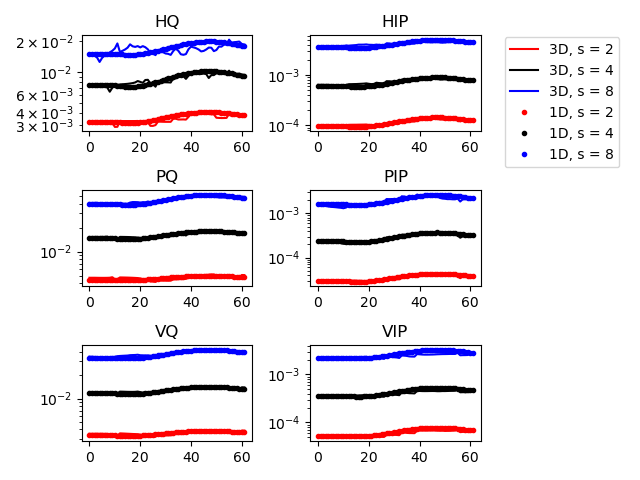

In [17]:
fig, ax = plt.subplots(3,2)

ax[0,0].semilogy(data_true[:,0], 'r', label='2')
ax[0,0].semilogy(data_true[:,1], 'k', label='4')
ax[0,0].semilogy(data_true[:,2], 'b', label='8')
ax[0,0].semilogy(data_1D[:,0], '.r', label='2')
ax[0,0].semilogy(data_1D[:,1], '.k', label='4')
ax[0,0].semilogy(data_1D[:,2], '.b', label='8')

ax[0,0].set_title('HQ')
#ax[0,0].legend()

ax[1,0].semilogy(data_true[:,3], 'r', label='2')
ax[1,0].semilogy(data_true[:,4], 'k', label='4')
ax[1,0].semilogy(data_true[:,5], 'b', label='8')
ax[1,0].semilogy(data_1D[:,3], '.r', label='2')
ax[1,0].semilogy(data_1D[:,4], '.k', label='4')
ax[1,0].semilogy(data_1D[:,5], '.b', label='8')
ax[1,0].set_title('PQ')
#ax[1,0].legend()

ax[2,0].semilogy(data_true[:,6], 'r', label='2')
ax[2,0].semilogy(data_true[:,7], 'k', label='4')
ax[2,0].semilogy(data_true[:,8], 'b', label='8')
ax[2,0].semilogy(data_1D[:,6], '.r', label='2')
ax[2,0].semilogy(data_1D[:,7], '.k', label='4')
ax[2,0].semilogy(data_1D[:,8], '.b', label='8')
ax[2,0].set_title('VQ')
#ax[2,0].legend()

ax[0,1].semilogy(data_true[:,9], 'r', label='3D, s = 2')
ax[0,1].semilogy(data_true[:,10], 'k', label='3D, s = 4')
ax[0,1].semilogy(data_true[:,11], 'b', label='3D, s = 8')
ax[0,1].semilogy(data_1D[:,9], '.r', label='1D, s = 2')
ax[0,1].semilogy(data_1D[:,10], '.k', label='1D, s = 4')
ax[0,1].semilogy(data_1D[:,11], '.b', label='1D, s = 8')
ax[0,1].set_title('HIP')
ax[0,1].legend(bbox_to_anchor=(1.1, 1.05))

ax[1,1].semilogy(data_true[:,12], 'r',  label='2')
ax[1,1].semilogy(data_true[:,13], 'k', label='4')
ax[1,1].semilogy(data_true[:,14], 'b', label='8')
ax[1,1].semilogy(data_1D[:,12], '.r', label='2')
ax[1,1].semilogy(data_1D[:,13], '.k', label='4')
ax[1,1].semilogy(data_1D[:,14], '.b', label='8')
ax[1,1].set_title('PIP')
#ax[1,1].legend()

ax[2,1].semilogy(data_true[:,15], 'r', label='2')
ax[2,1].semilogy(data_true[:,16], 'k', label='4')
ax[2,1].semilogy(data_true[:,17], 'b', label='8')
ax[2,1].semilogy(data_1D[:,15], '.r', label='2')
ax[2,1].semilogy(data_1D[:,16], '.k', label='4')
ax[2,1].semilogy(data_1D[:,17], '.b', label='8')
ax[2,1].set_title('VIP')
#ax[2,1].legend()

plt.tight_layout()